1. Obtenção e preparação dos dados. Baixe o arquivo
PDB da estrutura 6B1T a partir de https://www.
rcsb.org/structure/6B1T (opção de download do
pacote comprimido tar.gz). Para testes preliminares, selecione proteínas menores disponíveis no
mesmo repositório, que permitam validar a cadeia
de processamento sem sobrecarga de memória.

# Abrir arquivo

2. Leitura e parsing do arquivo PDB. Utilize pacote
específico ou implemente um leitor para extrair as
informações de cada átomo.

In [1]:
!pip install biopandas
!pip install prody

In [2]:
import pandas as pd
from biopandas.pdb import PandasPdb
from prody import parsePDBHeader
from typing import Optional, Tuple
import numpy as np
import tarfile
import tempfile

In [3]:
import os

In [4]:
caminho = 'Dados/6b1t-pdb-bundle.tar.gz'

print(os.path.exists(caminho))

True


In [5]:
def read_pdb_bundle_to_dataframe(tar_path: str, model_index: int = 1, parse_header: bool = True,) -> Tuple[pd.DataFrame, Optional[dict]]:

    with tempfile.TemporaryDirectory() as tmpdir:
        with tarfile.open(tar_path, "r:gz") as tar:
            pdb_member = next((m for m in tar.getmembers() if m.name.endswith('.pdb')), None)

            if not pdb_member:
                raise FileNotFoundError("Nenhum arquivo .pdb encontrado dentro do bundle .tar.gz")

            tar.extract(pdb_member, path=tmpdir)
            extracted_pdb_path = os.path.join(tmpdir, pdb_member.name)

            atomic_df = PandasPdb().read_pdb(extracted_pdb_path)

            header = None
            if parse_header:
                header = parsePDBHeader(extracted_pdb_path)

            atomic_df = atomic_df.get_model(model_index)


            atom_df = atomic_df.df.get("ATOM", pd.DataFrame())
            hetatm_df = atomic_df.df.get("HETATM", pd.DataFrame())

            if len(atom_df) == 0 and len(hetatm_df) == 0:
                raise ValueError(f"Nenhum modelo encontrado para o índice: {model_index}")

            # Junta os dataframes
            combined_df = pd.concat([atom_df, hetatm_df], ignore_index=True)

            return combined_df, header

In [6]:
df, df_header = read_pdb_bundle_to_dataframe(caminho)
df.head(10)

C:\Users\Micro\AppData\Local\Temp\ipykernel_18192\1430060886.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(pdb_member, path=tmpdir)


,record_name,atom_number,blank_1,atom_name,alt_loc,residue_name,blank_2,chain_id,residue_number,insertion,...,y_coord,z_coord,occupancy,b_factor,blank_4,segment_id,element_symbol,charge,line_idx,model_id
0,ATOM,1,,N,,MET,,A,6,,...,141.274,313.915,1.0,23.42,,,N,NaN,13,1
1,ATOM,2,,CA,,MET,,A,6,,...,140.119,314.084,1.0,23.42,,,C,NaN,14,1
2,ATOM,3,,C,,MET,,A,6,,...,138.972,314.755,1.0,23.42,,,C,NaN,15,1
3,ATOM,4,,O,,MET,,A,6,,...,137.863,314.225,1.0,23.42,,,O,NaN,16,1
4,ATOM,5,,CB,,MET,,A,6,,...,140.503,314.896,1.0,23.42,,,C,NaN,17,1
5,ATOM,6,,CG,,MET,,A,6,,...,141.510,314.193,1.0,23.42,,,C,NaN,18,1
6,ATOM,7,,SD,,MET,,A,6,,...,141.868,315.099,1.0,23.42,,,S,NaN,19,1
7,ATOM,8,,CE,,MET,,A,6,,...,142.879,316.414,1.0,23.42,,,C,NaN,20,1
8,ATOM,9,,N,,MET,,A,7,,...,139.255,315.929,1.0,18.70,,,N,NaN,21,1
9,ATOM,10,,CA,,MET,,A,7,,...,138.360,316.662,1.0,18.70,,,C,NaN,22,1


In [7]:
df.shape

(99926, 22)

# EXTRAIR INFORMAÇÃO ATOMO

In [8]:
df = df.drop_duplicates()

df_residuos_completo = df[df['atom_name'].astype(str).str.strip() == 'CA'].copy()
df_residuos_completo = df_residuos_completo.reset_index(drop=True)

df_residuos_completo['id_residuo'] = (
    df_residuos_completo['chain_id'].astype(str) + "_" +
    df_residuos_completo['residue_number'].astype(str) + "_" +
    df_residuos_completo['residue_name'].astype(str)
)


df_residuos = df_residuos_completo.copy()   #.iloc[:1000].copy()
df_residuos = df_residuos.reset_index(drop=True)

print("Total de átomos:", len(df))
print("Total de resíduos CA disponíveis:", len(df_residuos_completo))
print("Total de resíduos usados:", len(df_residuos))

df_residuos[['id_residuo', 'chain_id', 'residue_number', 'residue_name', 'atom_name', 'x_coord', 'y_coord', 'z_coord']].head()

Total de átomos: 99926
Total de resíduos CA disponíveis: 12516
Total de resíduos usados: 12516


,id_residuo,chain_id,residue_number,residue_name,atom_name,x_coord,y_coord,z_coord
0,A_6_MET,A,6,MET,CA,35.067,140.119,314.084
1,A_7_MET,A,7,MET,CA,32.891,138.360,316.662
2,A_8_PRO,A,8,PRO,CA,29.086,138.693,316.332
3,A_9_GLN,A,9,GLN,CA,28.686,139.419,320.045
4,A_10_TRP,A,10,TRP,CA,31.304,142.172,320.027


In [9]:
df.columns

Index(['record_name', 'atom_number', 'blank_1', 'atom_name', 'alt_loc',
       'residue_name', 'blank_2', 'chain_id', 'residue_number', 'insertion',
       'blank_3', 'x_coord', 'y_coord', 'z_coord', 'occupancy', 'b_factor',
       'blank_4', 'segment_id', 'element_symbol', 'charge', 'line_idx',
       'model_id'],
      dtype='object')

3. Construção da rede. Modele a proteína como um
grafo não-dirigido, podendo ser unitário ou ponde
rado. A definição das arestas pode considerar os
seguintes critérios:

* distância espacial;
* pertencer ao mesmo resíduo de aminoácido;
* diferentes cadeias;
* afinidade entre resíduos (i.e., hidrofobicidade,
carga, capacidade de formar pontes de H, da
dos tabelados);
* entropia mútua e correlação espacial;
* autoencoder + classificador n → 1;
* à critério do aluno;



A justificativa detalhada da modelagem deve cons
tar no relatório final, e deve ter uma boa funda
mentação.

# CONSIDERAR DISTANCIA

In [10]:
# Coordenadas dos resíduos representados pelo carbono alfa CA.
xs = df_residuos['x_coord'].to_numpy()
ys = df_residuos['y_coord'].to_numpy()
zs = df_residuos['z_coord'].to_numpy()

print("Quantidade de nós/resíduos:", len(xs))

Quantidade de nós/resíduos: 12516


In [11]:
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
def distancia_quadrada(amostra1, amostra2):
  dx = amostra1[0] - amostra2[0]
  dy = amostra1[1] - amostra2[1]
  dz = amostra1[2] - amostra2[2]

  return dx**2 + dy**2 + dz**2

In [13]:
def grafo_e_matriz(limiar, criar_matriz=True):
  n = len(xs)

  matriz = np.zeros((n, n), dtype=np.uint8)
  G = nx.Graph()

  for i in range(n):
    G.add_node(
        i,
        residuo=df_residuos.loc[i, 'residue_name'],
        cadeia=df_residuos.loc[i, 'chain_id'],
        numero_residuo=df_residuos.loc[i, 'residue_number'],
        x=df_residuos.loc[i, 'x_coord'],
        y=df_residuos.loc[i, 'y_coord'],
        z=df_residuos.loc[i, 'z_coord']
    )

  limiar_quadrado = limiar ** 2

  for i in range(n):
    amostra1 = (xs[i], ys[i], zs[i])

    for j in range(i + 1, n):
      amostra2 = (xs[j], ys[j], zs[j])
      dist2 = distancia_quadrada(amostra1, amostra2)

      if dist2 <= limiar_quadrado:
        if matriz is not None:
          matriz[i][j] = 1
          matriz[j][i] = 1

        G.add_edge(i, j)

  return G, matriz

In [14]:
def mostrar_matriz(matriz):
  plt.figure(figsize=(6, 6))
  plt.imshow(matriz)
  plt.title("Matriz de adjacência")
  plt.show()

In [15]:
def mostrar_grafo_3D(G):
  if G.number_of_nodes() > 2000:
    print("Grafo muito grande para desenhar com spring_layout. Use a visualização 3D das comunidades.")
    return

  pos = nx.spring_layout(G, seed=42, k=0.4)

  plt.figure(figsize=(12, 12))

  nx.draw_networkx_nodes(G, pos, node_size=60, alpha=0.8)
  nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.5)

  top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:30]
  labels = {n: n for n, _ in top_nodes}

  nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

  plt.axis("off")
  plt.show()

In [16]:
def mostrar_distribuicao_grau(G):
  graus = dict(G.degree())
  valores = list(graus.values())

  dist = {}
  for g in valores:
      if g in dist:
          dist[g] += 1
      else:
          dist[g] = 1

  x, y = zip(*sorted(dist.items()))

  plt.bar(x, y)
  plt.xlabel('Grau')
  plt.ylabel('Frequência')
  plt.show()

In [17]:
def centralidades(G):
    graus = dict(G.degree())
    degree_cent = nx.degree_centrality(G)
    bet_cent = nx.betweenness_centrality(G)
    close_cent = nx.closeness_centrality(G)
    # clustering = nx.clustering(G)

    resumo_centralidades = pd.DataFrame({
        "grau": pd.Series(graus),
        "degree_centrality": pd.Series(degree_cent),
        "betweenness_centrality": pd.Series(bet_cent),
        "closeness_centrality": pd.Series(close_cent),
        # "clustering_coef": pd.Series(clustering),
    }).sort_values(by="grau", ascending=False)

    print(resumo_centralidades.head(20))

In [18]:
import time

limiar1 = 7.0
limiar2 = 8.0
limiar3 = 8.5
limiar4 = 10.0
limiar5 = 15.0
limiar6 = 17.0

limiares = [limiar1, limiar2, limiar3, limiar4, limiar5]

grafos = []
matrizes = []

for limiar in limiares:
    inicio = time.time()
    G_atual, matriz_atual = grafo_e_matriz(limiar)
    fim = time.time()

    grafos.append(G_atual)
    matrizes.append(matriz_atual)

    print("Limiar:", limiar)
    print("Nós:", G_atual.number_of_nodes())
    print("Arestas:", G_atual.number_of_edges())
    print("Nós isolados:", nx.number_of_isolates(G_atual))
    print("Tempo:", round(fim - inicio, 2), "segundos")
    print()

Limiar: 7.0
Nós: 12516
Arestas: 51359
Nós isolados: 0
Tempo: 48.48 segundos

Limiar: 8.0
Nós: 12516
Arestas: 66608
Nós isolados: 0
Tempo: 47.79 segundos

Limiar: 8.5
Nós: 12516
Arestas: 77223
Nós isolados: 0
Tempo: 48.06 segundos

Limiar: 10.0
Nós: 12516
Arestas: 127300
Nós isolados: 0
Tempo: 48.56 segundos

Limiar: 15.0
Nós: 12516
Arestas: 406715
Nós isolados: 0
Tempo: 48.81 segundos



In [19]:
# for m in matrizes:
#     mostrar_matriz(m)

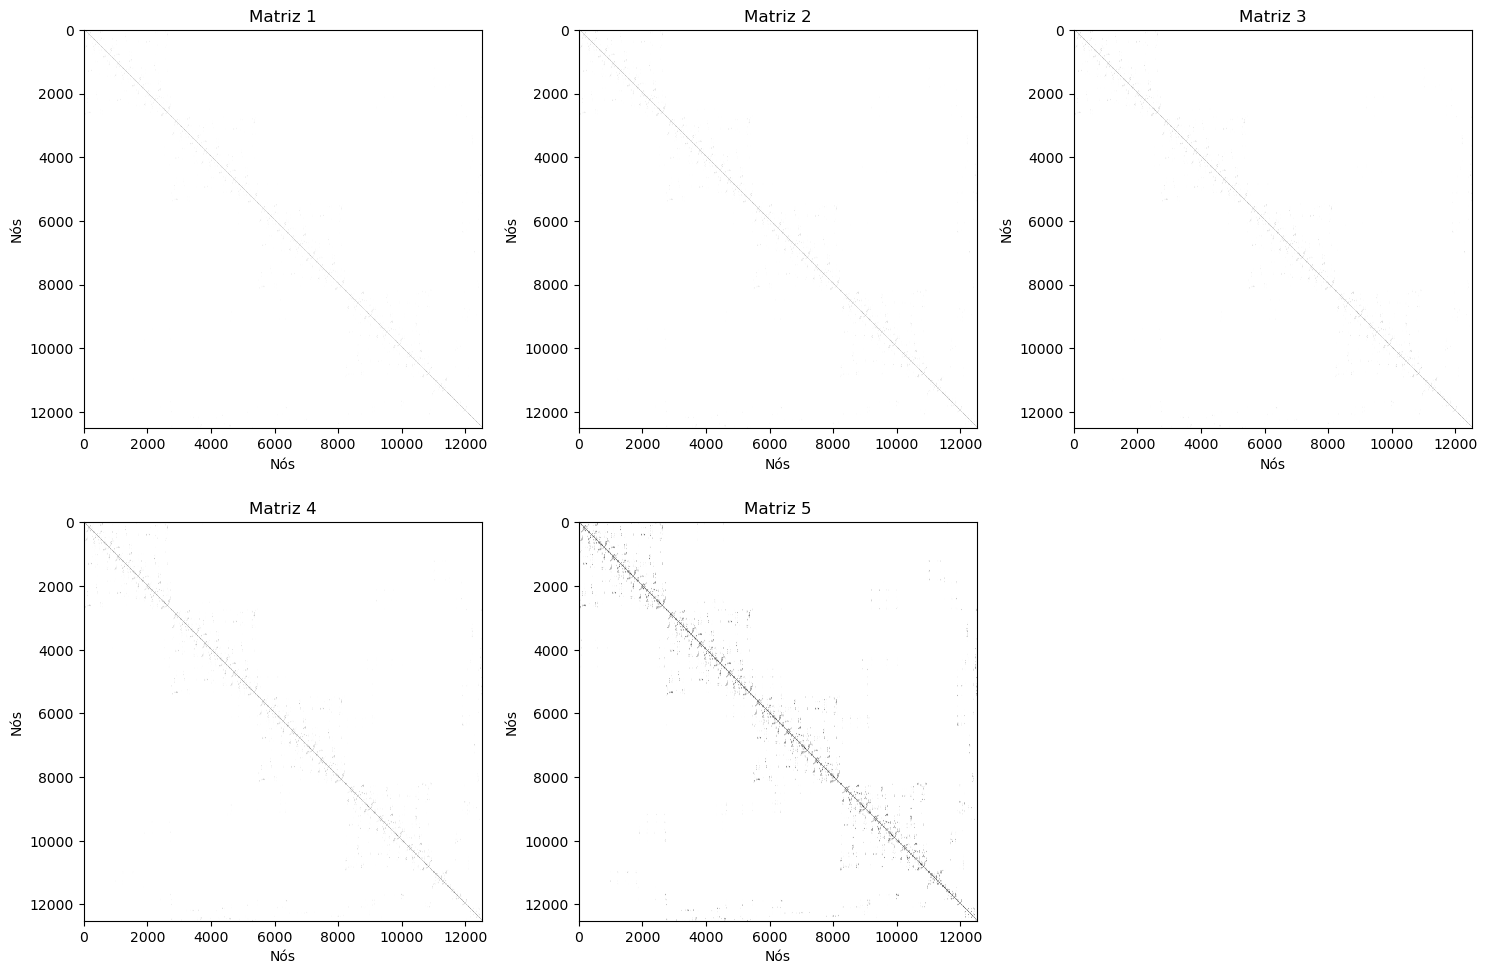

In [20]:
import matplotlib.pyplot as plt
import math

def salvar_matrizes_juntas(matrizes, nomes=None, arquivo="matrizes_juntas.png"):
    qtd = len(matrizes)

    colunas = 3
    linhas = math.ceil(qtd / colunas)

    fig, axs = plt.subplots(linhas, colunas, figsize=(5 * colunas, 5 * linhas))

    axs = axs.flatten()

    for i, matriz in enumerate(matrizes):
        axs[i].imshow(matriz, cmap="gray_r")
        
        if nomes is not None:
            axs[i].set_title(nomes[i])
        else:
            axs[i].set_title(f"Matriz {i+1}")

        axs[i].set_xlabel("Nós")
        axs[i].set_ylabel("Nós")

    # Apaga espaços vazios se tiver menos matrizes que subplots
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.savefig(arquivo, dpi=300, bbox_inches="tight")
    plt.show()
salvar_matrizes_juntas(matrizes)

4. Análise topológica da rede. Calcule e interprete as
seguintes medidas:
* distribuição de graus ;
* centralidades convenientes ;

Relacione os resultados com a estrutura tridimen
sional esperada

In [21]:
for i, grafo in enumerate(grafos):
    print("Grafo", i + 1, "- limiar", limiares[i])
    centralidades(grafo)
    print()

Grafo 1 - limiar 7.0
       grau  degree_centrality  betweenness_centrality  closeness_centrality
9899     15           0.001199                0.004332              0.045381
8075     14           0.001119                0.000831              0.037646
795      14           0.001119                0.000997              0.038409
3606     14           0.001119                0.002075              0.045068
2702     14           0.001119                0.014684              0.056175
2011     14           0.001119                0.001151              0.037616
1965     14           0.001119                0.000544              0.038623
7468     14           0.001119                0.002429              0.034930
9073     14           0.001119                0.016190              0.057431
879      14           0.001119                0.001093              0.042946
4690     14           0.001119                0.000234              0.043729
11217    14           0.001119                0.000185 

Grafo 1 - limiar 7.0


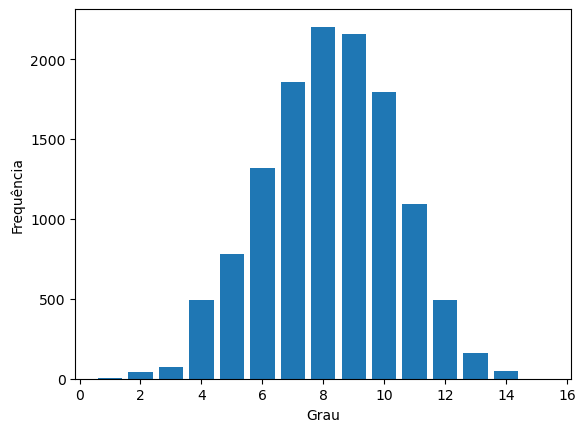

Grafo 2 - limiar 8.0


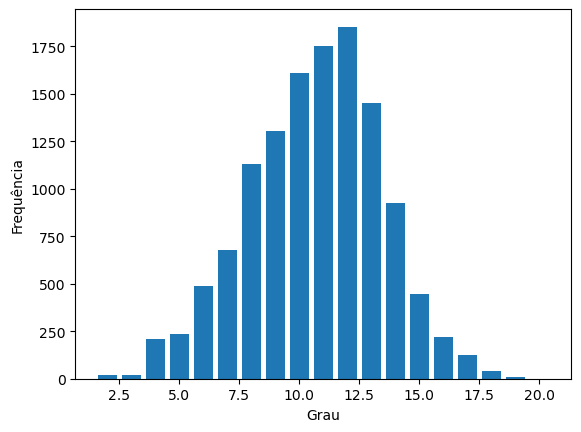

Grafo 3 - limiar 8.5


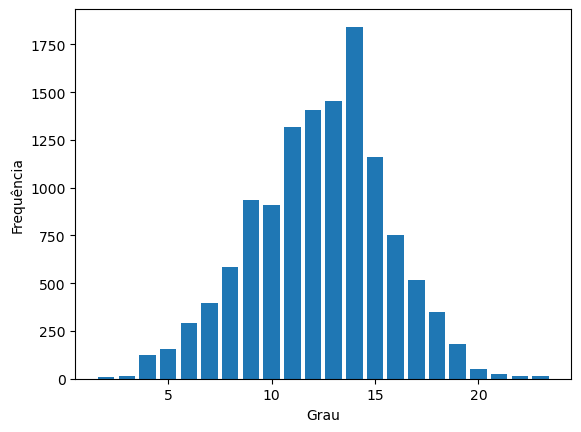

Grafo 4 - limiar 10.0


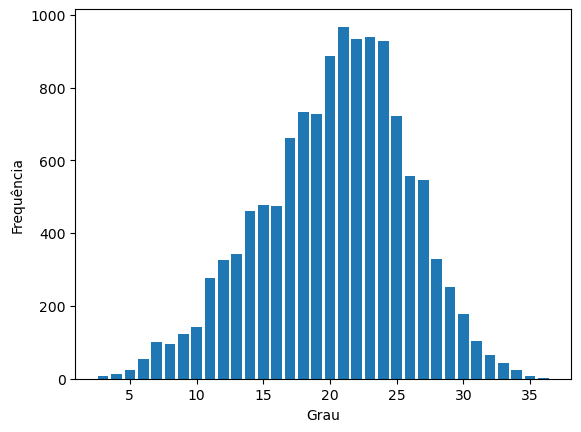

Grafo 5 - limiar 15.0


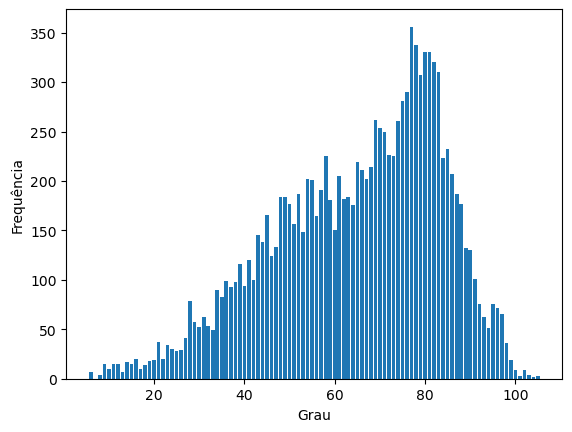

In [22]:
for i, grafo in enumerate(grafos):
    print("Grafo", i + 1, "- limiar", limiares[i])
    mostrar_distribuicao_grau(grafo)

# *COMUNIDADES*

5. Detecção de comunidades. Aplique ao menos um
algoritmos de detecção de comunidades (ex.: Lou
vain, Infomap, ou Bipartição espectral). Reporte o
número de comunidades encontradas

In [23]:
ensemble = []
comunidades_resultados = []
modularities = []

for i, grafo in enumerate(grafos):
    comunidades_grafo = nx.community.louvain_communities(
        grafo,
        seed=321
    )

    modularidade = nx.community.modularity(grafo, comunidades_grafo)

    ensemble.append(grafo)
    comunidades_resultados.append(comunidades_grafo)
    modularities.append(modularidade)

    print("Grafo", i + 1)
    print("Limiar:", limiares[i])
    print("Nós:", grafo.number_of_nodes())
    print("Arestas:", grafo.number_of_edges())
    print("Nós isolados:", nx.number_of_isolates(grafo))
    print("Número de comunidades:", len(comunidades_grafo))
    print("Modularidade:", modularidade)
    print()

indice_melhor = int(np.argmax(modularities))
G_melhor = grafos[indice_melhor]
comunidades_melhor = comunidades_resultados[indice_melhor]
limiar_melhor = limiares[indice_melhor]

print("Melhor grafo pela modularidade:")
print("Grafo:", indice_melhor + 1)
print("Limiar:", limiar_melhor)
print("Modularidade:", modularities[indice_melhor])

Grafo 1
Limiar: 7.0
Nós: 12516
Arestas: 51359
Nós isolados: 0
Número de comunidades: 39
Modularidade: 0.9177503387217539

Grafo 2
Limiar: 8.0
Nós: 12516
Arestas: 66608
Nós isolados: 0
Número de comunidades: 32
Modularidade: 0.8957664405287992

Grafo 3
Limiar: 8.5
Nós: 12516
Arestas: 77223
Nós isolados: 0
Número de comunidades: 29
Modularidade: 0.8894037613204732

Grafo 4
Limiar: 10.0
Nós: 12516
Arestas: 127300
Nós isolados: 0
Número de comunidades: 20
Modularidade: 0.8616185200018018

Grafo 5
Limiar: 15.0
Nós: 12516
Arestas: 406715
Nós isolados: 0
Número de comunidades: 15
Modularidade: 0.8139337153551136

Melhor grafo pela modularidade:
Grafo: 1
Limiar: 7.0
Modularidade: 0.9177503387217539


# Avaliação comparação das comunidades com cadeia e anotação

In [24]:
df_residuos['comunidade'] = -1

for id_comunidade, comunidade in enumerate(comunidades_melhor):
    for no in comunidade:
        df_residuos.loc[no, 'comunidade'] = id_comunidade

df_residuos[['chain_id', 'residue_number', 'residue_name', 'comunidade']].head()

,chain_id,residue_number,residue_name,comunidade
0,A,6,MET,6
1,A,7,MET,6
2,A,8,PRO,6
3,A,9,GLN,6
4,A,10,TRP,6


In [25]:
# Tabela absoluta: comunidade x cadeia
tabela = pd.crosstab(
    df_residuos['comunidade'],
    df_residuos['chain_id']
)

tabela

chain_id,A,B,C,D,E,F,G,H,I,J,...,O,P,Q,R,S,T,U,V,W,X
comunidade,,,,,,,,,,,,,,,,,,,,,
0,323,45,280,0,6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,243,139,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,56,112,177,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,371,60,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,74,173,41,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,169,42,97,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,43,27,249,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
7,0,0,0,209,0,53,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,285,55,0,0,0,0,0,...,0,0,0,47,0,0,8,0,11,19


In [26]:
# Tabela percentual: comunidade x cadeia
tabela_percentual = pd.crosstab(
    df_residuos['comunidade'],
    df_residuos['chain_id'],
    normalize='index'
) * 100

tabela_percentual.round(2)

chain_id,A,B,C,D,E,F,G,H,I,J,...,O,P,Q,R,S,T,U,V,W,X
comunidade,,,,,,,,,,,,,,,,,,,,,
0,49.39,6.88,42.81,0.00,0.92,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
1,63.61,36.39,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
2,16.23,32.46,51.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
3,0.00,86.08,13.92,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
4,25.69,60.07,14.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
5,54.87,13.64,31.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
6,12.39,7.78,71.76,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.58,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
7,0.00,0.00,0.00,79.77,0.00,20.23,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
8,0.00,0.00,0.00,67.06,12.94,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,11.06,0.00,0.00,1.88,0.0,2.59,4.47


In [27]:
# Tabela percentual: comunidade x cadeia
tabela_percentual = pd.crosstab(
    df_residuos['comunidade'],
    df_residuos['chain_id'],
    normalize='index'
) * 100

tabela_percentual.round(2)

chain_id,A,B,C,D,E,F,G,H,I,J,...,O,P,Q,R,S,T,U,V,W,X
comunidade,,,,,,,,,,,,,,,,,,,,,
0,49.39,6.88,42.81,0.00,0.92,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
1,63.61,36.39,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
2,16.23,32.46,51.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
3,0.00,86.08,13.92,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
4,25.69,60.07,14.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
5,54.87,13.64,31.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
6,12.39,7.78,71.76,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.58,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
7,0.00,0.00,0.00,79.77,0.00,20.23,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
8,0.00,0.00,0.00,67.06,12.94,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,11.06,0.00,0.00,1.88,0.0,2.59,4.47


In [28]:
# Pureza por cadeia: quanto mais perto de 1, melhor.
tabela = pd.crosstab(
    df_residuos['comunidade'],
    df_residuos['chain_id']
)

maiores_valores = tabela.max(axis=1)
total_nos = tabela.sum().sum()

pureza = maiores_valores.sum() / total_nos

print("Pureza por cadeia:", pureza)

Pureza por cadeia: 0.6690635985937999


In [29]:
mapa_anotacao = {}

df_residuos['anotacao'] = df_residuos['chain_id'].map(mapa_anotacao)
df_residuos['anotacao'] = df_residuos['anotacao'].fillna('Outra')

df_residuos[['chain_id', 'residue_number', 'residue_name', 'comunidade', 'anotacao']].head()

,chain_id,residue_number,residue_name,comunidade,anotacao
0,A,6,MET,6,Outra
1,A,7,MET,6,Outra
2,A,8,PRO,6,Outra
3,A,9,GLN,6,Outra
4,A,10,TRP,6,Outra


In [30]:
comparacao = pd.crosstab(
    df_residuos['comunidade'],
    df_residuos['anotacao']
)

comparacao_percentual = pd.crosstab(
    df_residuos['comunidade'],
    df_residuos['anotacao'],
    normalize='index'
) * 100

print("Comparação absoluta:")
display(comparacao)

print("Comparação percentual:")
display(comparacao_percentual.round(2))

Comparação absoluta:


anotacao,Outra
comunidade,
0,654
1,382
2,345
3,431
4,288
5,308
6,347
7,262
8,425


Comparação percentual:


anotacao,Outra
comunidade,
0,100.0
1,100.0
2,100.0
3,100.0
4,100.0
5,100.0
6,100.0
7,100.0
8,100.0


# Visualização 3D das comunidades

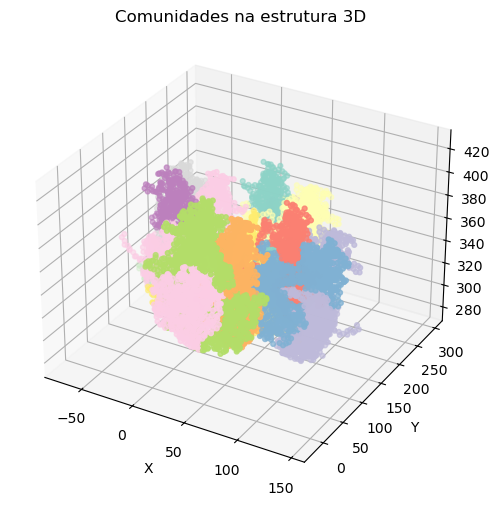

In [31]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_residuos['x_coord'],
    df_residuos['y_coord'],
    df_residuos['z_coord'],
    c=df_residuos['comunidade'],
    cmap='Set3',
    s=12
)

ax.set_title("Comunidades na estrutura 3D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [32]:
mapa_anotacao = {
    # Hexon
    'A': 'Hexon',
    'B': 'Hexon',
    'C': 'Hexon',
    'D': 'Hexon',
    'E': 'Hexon',
    'F': 'Hexon',
    'G': 'Hexon',
    'H': 'Hexon',
    'I': 'Hexon',
    'J': 'Hexon',
    'K': 'Hexon',
    'L': 'Hexon',

    # Penton
    'M': 'Penton'
}

df_residuos['anotacao'] = df_residuos['chain_id'].map(mapa_anotacao)
df_residuos['anotacao'] = df_residuos['anotacao'].fillna('Outra')

In [33]:
comparacao = pd.crosstab(
    df_residuos['comunidade'],
    df_residuos['anotacao']
)

comparacao

anotacao,Hexon,Outra,Penton
comunidade,,,
0,654,0,0
1,382,0,0
2,345,0,0
3,431,0,0
4,288,0,0
5,308,0,0
6,345,2,0
7,262,0,0
8,340,85,0


In [34]:
df_minimo = df_residuos[df_residuos['anotacao'].isin(['Hexon', 'Penton'])]

validacao_minima = pd.crosstab(
    df_minimo['comunidade'],
    df_minimo['anotacao']
)

validacao_minima

anotacao,Hexon,Penton
comunidade,,
0,654,0
1,382,0
2,345,0
3,431,0
4,288,0
5,308,0
6,345,0
7,262,0
8,340,0


In [35]:
tabela = pd.crosstab(
    df_minimo['comunidade'],
    df_minimo['anotacao']
)

pureza_minima = tabela.max(axis=1).sum() / tabela.sum().sum()

print("Pureza mínima Hexon/Penton:", pureza_minima)

Pureza mínima Hexon/Penton: 0.9999121265377856


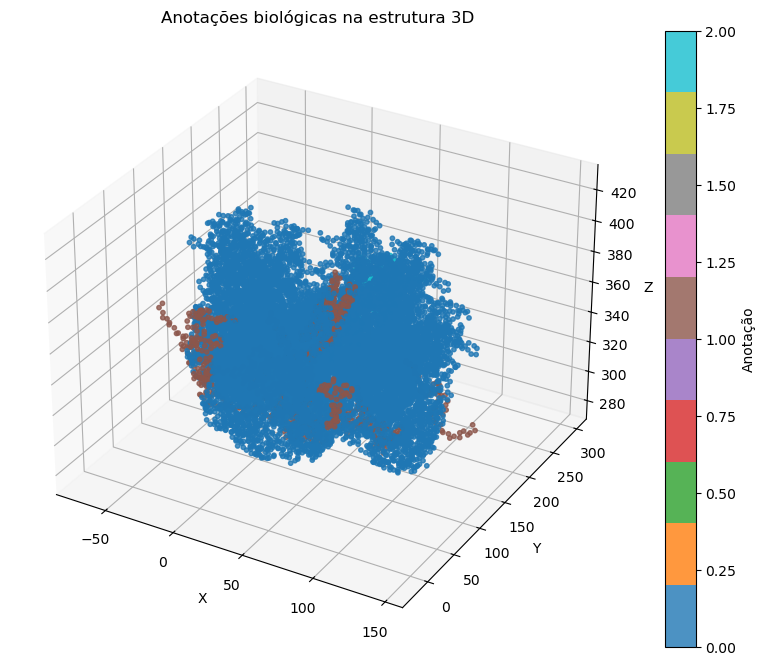

In [36]:
import matplotlib.pyplot as plt

df_plot = df_residuos.copy()

df_plot['anotacao_num'] = df_plot['anotacao'].astype('category').cat.codes

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

pontos = ax.scatter(
    df_plot['x_coord'],
    df_plot['y_coord'],
    df_plot['z_coord'],
    c=df_plot['anotacao_num'],
    cmap='tab10',
    s=10,
    alpha=0.8
)

ax.set_title("Anotações biológicas na estrutura 3D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.colorbar(pontos, ax=ax, label="Anotação")
plt.show()

In [40]:
df_residuos[df_residuos['anotacao'] == 'Penton']

,record_name,atom_number,blank_1,atom_name,alt_loc,residue_name,blank_2,chain_id,residue_number,insertion,...,b_factor,blank_4,segment_id,element_symbol,charge,line_idx,model_id,id_residuo,comunidade,anotacao
10925,ATOM,87639,,CA,,ASP,,M,37,,...,49.03,,,C,NaN,87651,1,M_37_ASP,32,Penton
10926,ATOM,87647,,CA,,PRO,,M,38,,...,43.80,,,C,NaN,87659,1,M_38_PRO,32,Penton
10927,ATOM,87654,,CA,,PRO,,M,39,,...,35.18,,,C,NaN,87666,1,M_39_PRO,32,Penton
10928,ATOM,87661,,CA,,PHE,,M,40,,...,29.86,,,C,NaN,87673,1,M_40_PHE,32,Penton
10929,ATOM,87672,,CA,,VAL,,M,41,,...,25.73,,,C,NaN,87684,1,M_41_VAL,32,Penton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11375,ATOM,91240,,CA,,SER,,M,567,,...,27.00,,,C,NaN,91252,1,M_567_SER,31,Penton
11376,ATOM,91246,,CA,,SER,,M,568,,...,26.29,,,C,NaN,91258,1,M_568_SER,31,Penton
11377,ATOM,91252,,CA,,ARG,,M,569,,...,26.28,,,C,NaN,91264,1,M_569_ARG,31,Penton
11378,ATOM,91263,,CA,,THR,,M,570,,...,24.64,,,C,NaN,91275,1,M_570_THR,31,Penton


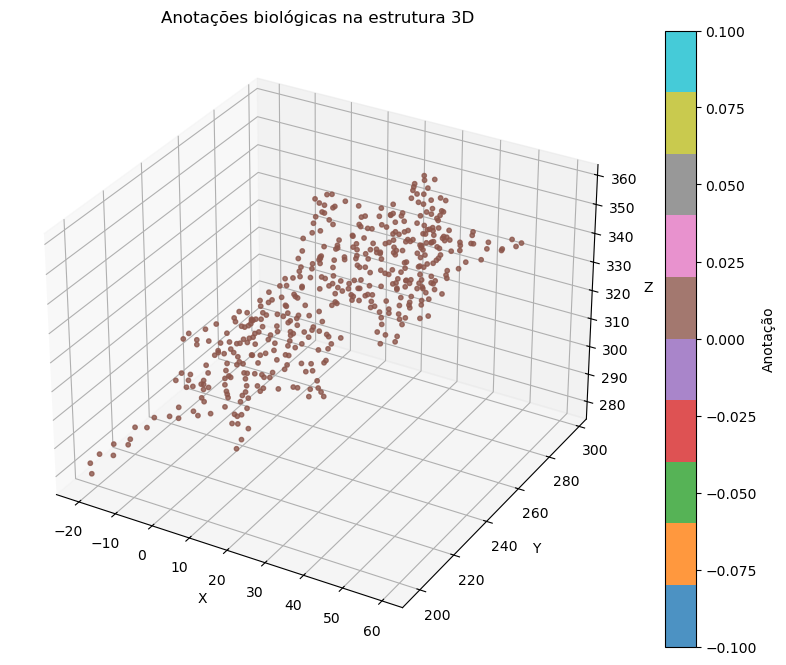

In [41]:
import matplotlib.pyplot as plt

df_plot = df_residuos[df_residuos['anotacao'] == 'Penton'].copy()

df_plot['anotacao_num'] = df_plot['anotacao'].astype('category').cat.codes

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

pontos = ax.scatter(
    df_plot['x_coord'],
    df_plot['y_coord'],
    df_plot['z_coord'],
    c=df_plot['anotacao_num'],
    cmap='tab10',
    s=10,
    alpha=0.8
)

ax.set_title("Anotações biológicas na estrutura 3D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.colorbar(pontos, ax=ax, label="Anotação")
plt.show()

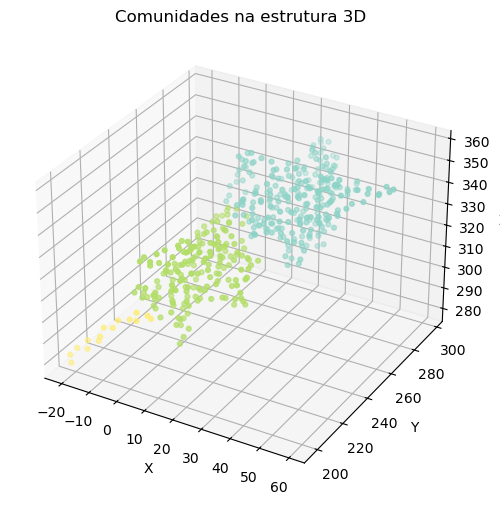

In [42]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_plot['x_coord'],
    df_plot['y_coord'],
    df_plot['z_coord'],
    c=df_plot['comunidade'],
    cmap='Set3',
    s=12
)

ax.set_title("Comunidades na estrutura 3D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

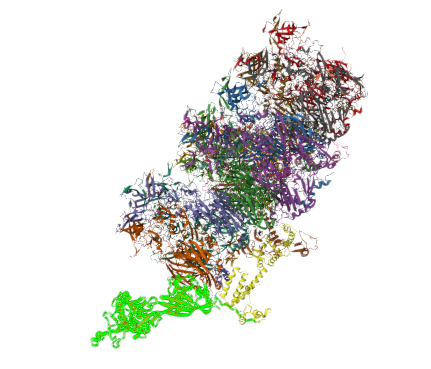

In [60]:
from scipy.spatial import ConvexHull

pts = df_plot[['x_coord','y_coord','z_coord']].values

hull = ConvexHull(pts)

# índices dos vértices da casca convexa
hull.vertices

array([  0,   1,   2,  21,  22,  44,  62,  63,  64,  65,  68,  71, 118,
       119, 161, 185, 231, 257, 258, 259, 260, 270, 280, 299, 300, 333,
       335, 337, 338, 361, 362, 369, 372, 373, 375, 453, 454], dtype=int32)

In [61]:
len(hull.vertices)

37

In [62]:
len(hull.simplices)

70

In [63]:
hull.simplices

array([[161, 270, 118],
       [161, 270, 375],
       [361, 362, 259],
       [257, 270, 375],
       [257, 372, 259],
       [257, 372, 375],
       [ 64,  63,   1],
       [  2, 361, 362],
       [119, 280, 299],
       [119, 333, 118],
       [119, 270, 118],
       [119, 257, 270],
       [185, 280, 299],
       [369, 362, 259],
       [369, 372, 259],
       [369,   2, 362],
       [373,  63, 375],
       [373, 372, 375],
       [373, 369, 372],
       [373,   2,   1],
       [373, 369,   2],
       [335, 337, 118],
       [335, 333, 118],
       [ 44, 161, 375],
       [ 44, 161, 118],
       [ 22,  64,   1],
       [ 22,  64,  68],
       [300, 333, 299],
       [300, 119, 299],
       [258, 257, 259],
       [258, 119, 257],
       [ 62,  63,   1],
       [ 62, 373,   1],
       [ 62, 373,  63],
       [454, 335, 333],
       [454, 333, 299],
       [454, 335, 337],
       [ 65,  64,  68],
       [ 65,  44,  68],
       [ 65,  44, 375],
       [ 65,  63, 375],
       [ 65,  64

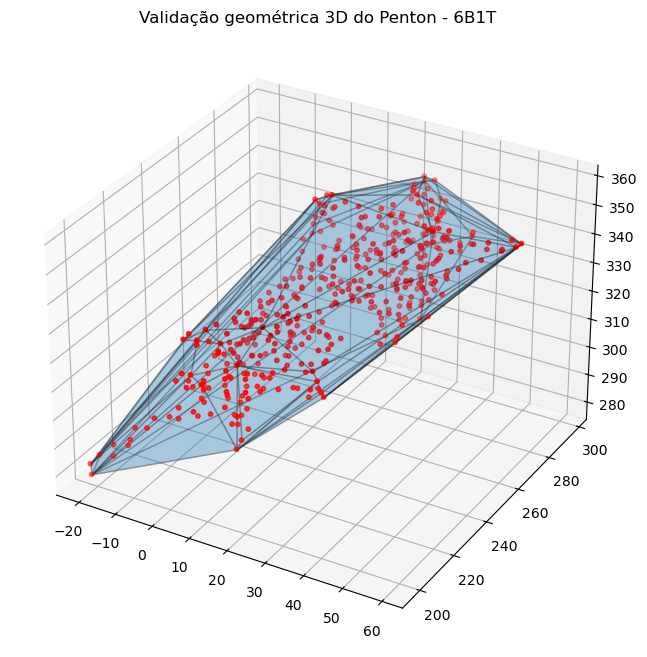

In [70]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pts[:,0],
    pts[:,1],
    pts[:,2],
    color='red',
    s=10
)
ax.set_title("Validação geométrica 3D do Penton - 6B1T")
for simplex in hull.simplices:
    tri = pts[simplex]
    ax.add_collection3d(
        Poly3DCollection(
            [tri],
            alpha=0.2,
            edgecolor='k'
        )
    )

plt.show()

In [68]:
print("Total de pontos do Penton:", len(df_plot))
print("Comunidades dentro do Penton:", sorted(df_plot["comunidade"].unique()))
print("Número de comunidades:", df_plot["comunidade"].nunique())

print("Vértices:", len(hull.vertices))
print("Faces triangulares:", len(hull.simplices))
print("Área:", hull.area)
print("Volume:", hull.volume)

percentual_vertices = len(hull.vertices) / len(df_plot) * 100
print(f"Percentual de resíduos na superfície: {percentual_vertices:.2f}%")

Total de pontos do Penton: 455
Comunidades dentro do Penton: [np.int64(30), np.int64(31), np.int64(32)]
Número de comunidades: 3
Vértices: 37
Faces triangulares: 70
Área: 14168.898277190325
Volume: 111390.83979153729
Percentual de resíduos na superfície: 8.13%


In [69]:
vertices_penton = df_plot.iloc[hull.vertices]

vertices_penton[
    ["id_residuo", "chain_id", "residue_number", "residue_name", "comunidade", "anotacao"]
]

,id_residuo,chain_id,residue_number,residue_name,comunidade,anotacao
10925,M_37_ASP,M,37,ASP,32,Penton
10926,M_38_PRO,M,38,PRO,32,Penton
10927,M_39_PRO,M,39,PRO,32,Penton
10946,M_58_SER,M,58,SER,31,Penton
10947,M_59_GLU,M,59,GLU,31,Penton
10969,M_81_SER,M,81,SER,31,Penton
10987,M_99_ASN,M,99,ASN,31,Penton
10988,M_100_ASP,M,100,ASP,31,Penton
10989,M_101_TYR,M,101,TYR,31,Penton
10990,M_102_SER,M,102,SER,31,Penton
